# Network Science Assignment 3

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 14. October 2024

In [156]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import pearsonr, spearmanr, kendalltau
import glob

In [157]:
# create accessibility helper for the given data and load it
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1

### Compute degree, closeness, betweenness and eigenvector centrality for each node.

In [180]:
# initialize a flattened figure
def initialize_figure(COLS, ROWS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(5 * COLS, 5 * ROWS))
    axes = axes.flatten() 

    return fig, axes

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

def plot_dist(centrality, ax, title):
    bins = np.logspace(np.log10(min(centrality)), np.log10(max(centrality)), 20)

    ax.hist(centrality, bins=bins, density=True, edgecolor='black') 
    ax.set_xscale('log')
    ax.set_yscale('log')
    set_ax_labels(ax, "k", "Distribution", f"{title}")

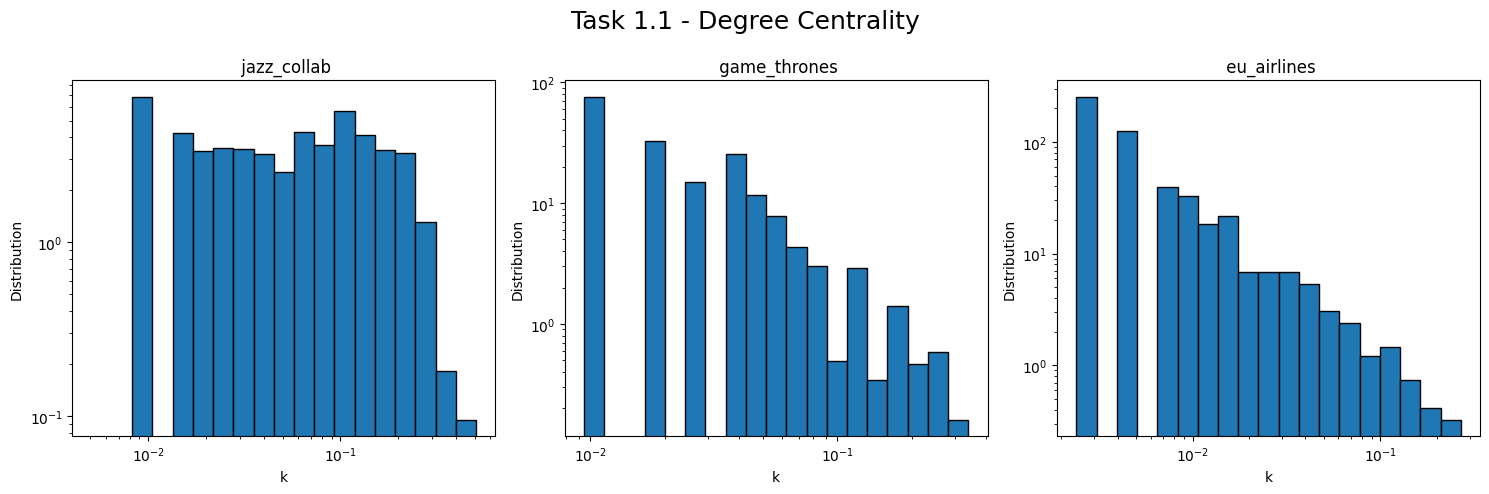

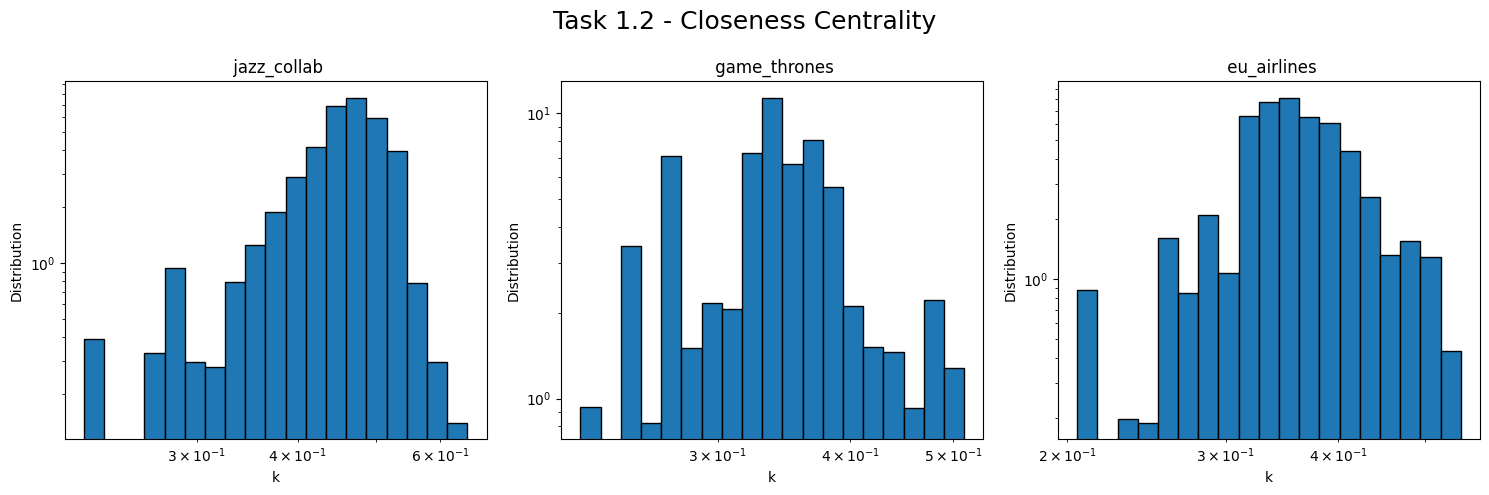

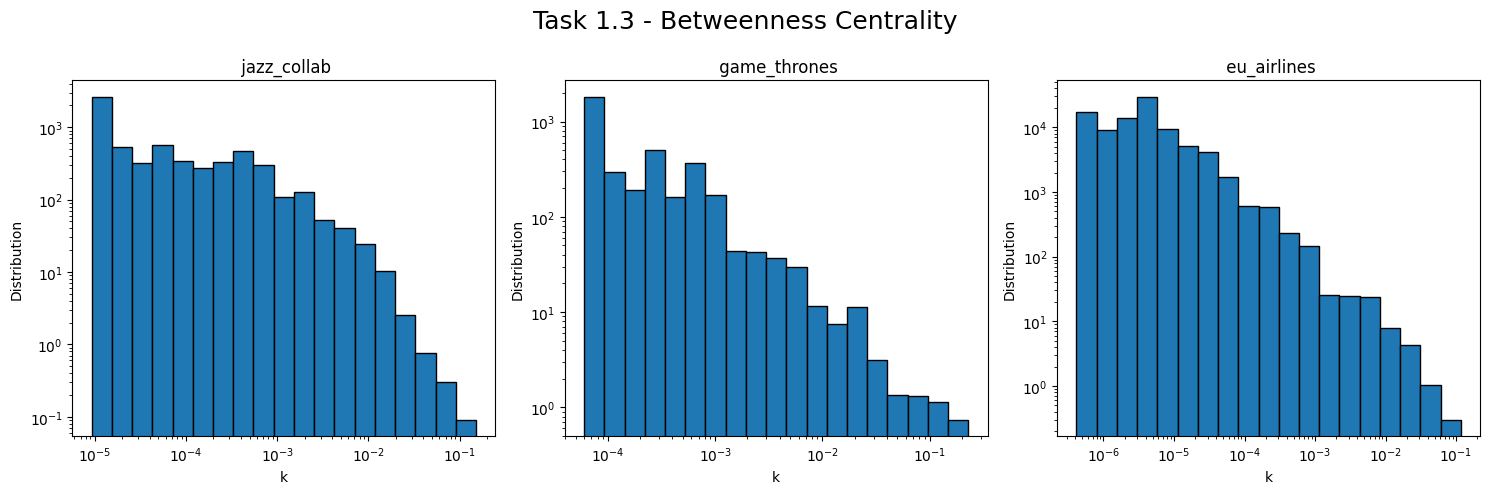

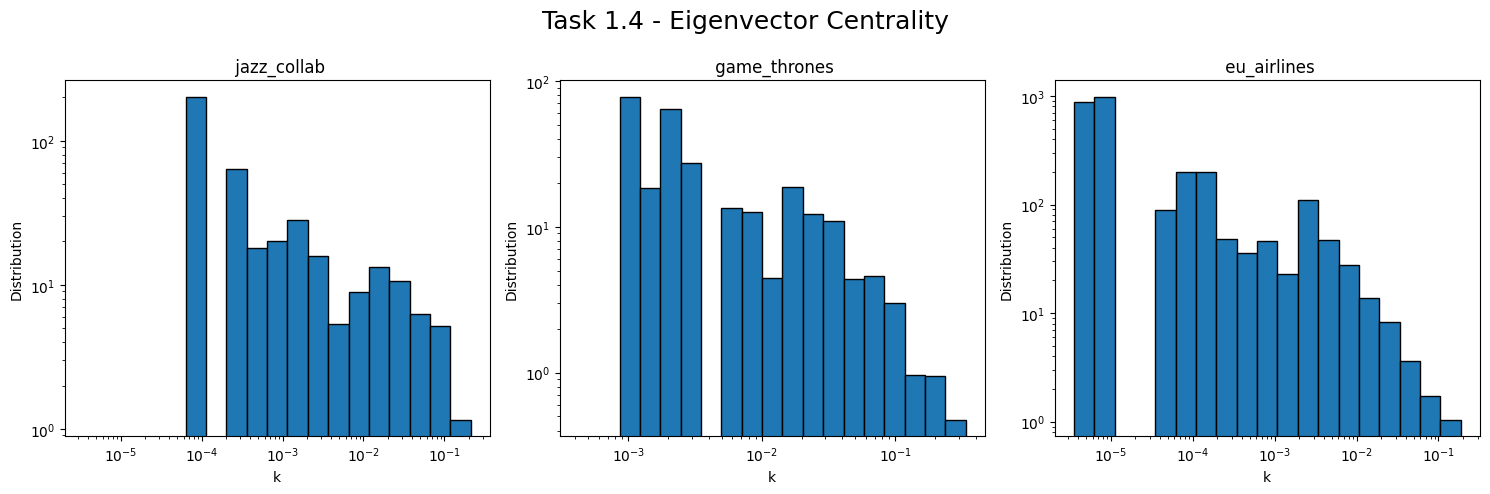

In [181]:
def plot_centrality(G, centrality_func, ax, title, filter_zero=False):
    centrality = list(centrality_func(G).values())
    
    if filter_zero:
        centrality = [c for c in centrality if c > 0]
    
    plot_dist(centrality, ax, title)

def plot_degree_centrality(G, ax, title):
    plot_centrality(G, nx.degree_centrality, ax, title)

def plot_closeness_centrality(G, ax, title):
    plot_centrality(G, nx.closeness_centrality, ax, title)

def plot_betweenness_centrality(G, ax, title):
    plot_centrality(G, nx.betweenness_centrality, ax, title, filter_zero=True)

def plot_eigenvector_centrality(G, ax, title):
    plot_centrality(G, nx.eigenvector_centrality, ax, title)

# main function for Task 4, iterating over all data
def main_degree_centrality(data_list, centrality, title):
    fig, axes = initialize_figure(3,1)
    for i, G in enumerate(data_list):
        centrality(G, axes[i], title=data_names[i])
        
    fig.suptitle(f"{title}", fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99]) 
    plt.show()


plot_func_title_pairs = [
    (plot_degree_centrality, "Task 1.1 - Degree Centrality"),
    (plot_closeness_centrality, "Task 1.2 - Closeness Centrality"),
    (plot_betweenness_centrality, "Task 1.3 - Betweenness Centrality"),
    (plot_eigenvector_centrality, "Task 1.4 - Eigenvector Centrality")
]

for (func, title) in plot_func_title_pairs:
    main_degree_centrality(data_lst, func, title)


## Task 2

### Do a scatter plot of each pair of centralities (6 plots total). Compute the Pearson, Spearman and Kendall correlation coefficient for each pair and note them on the scatter plots

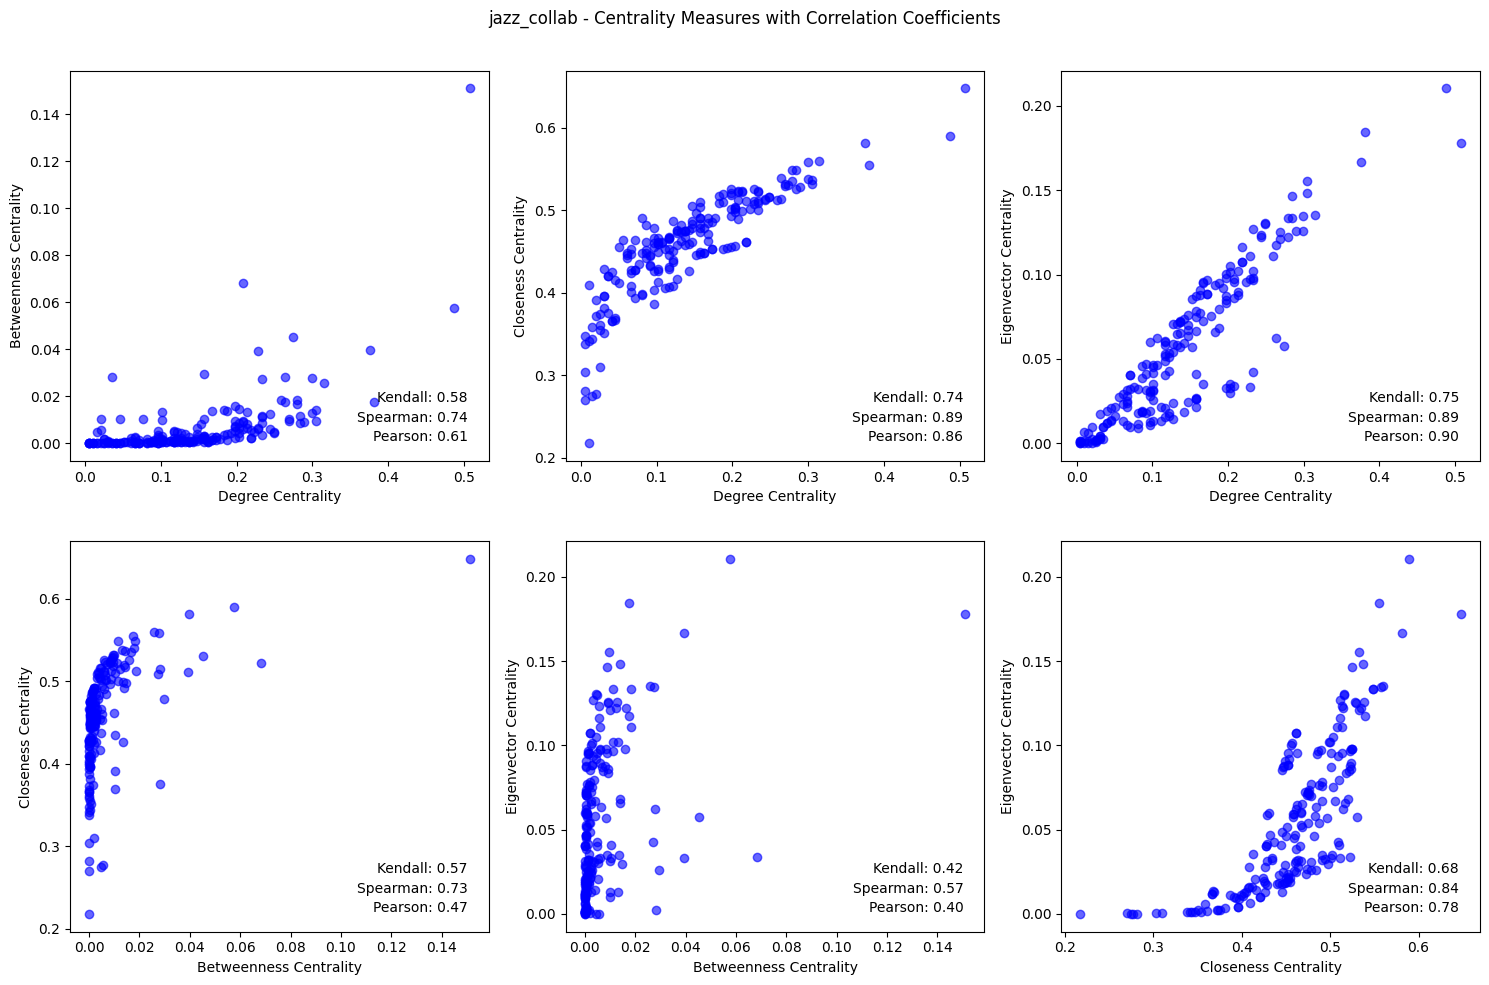

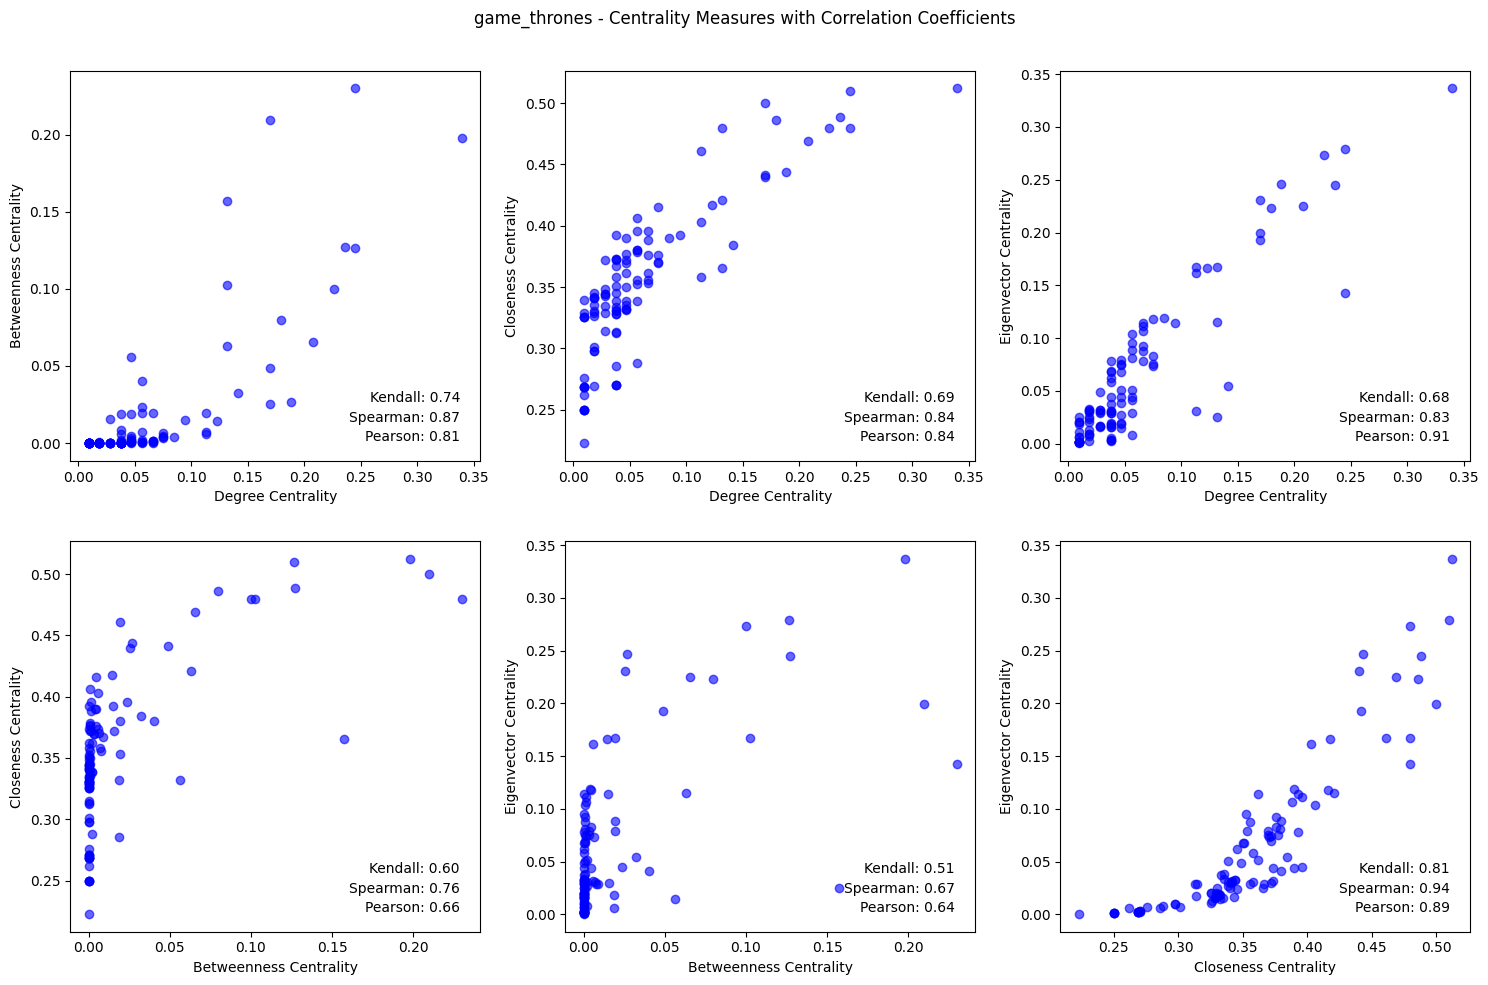

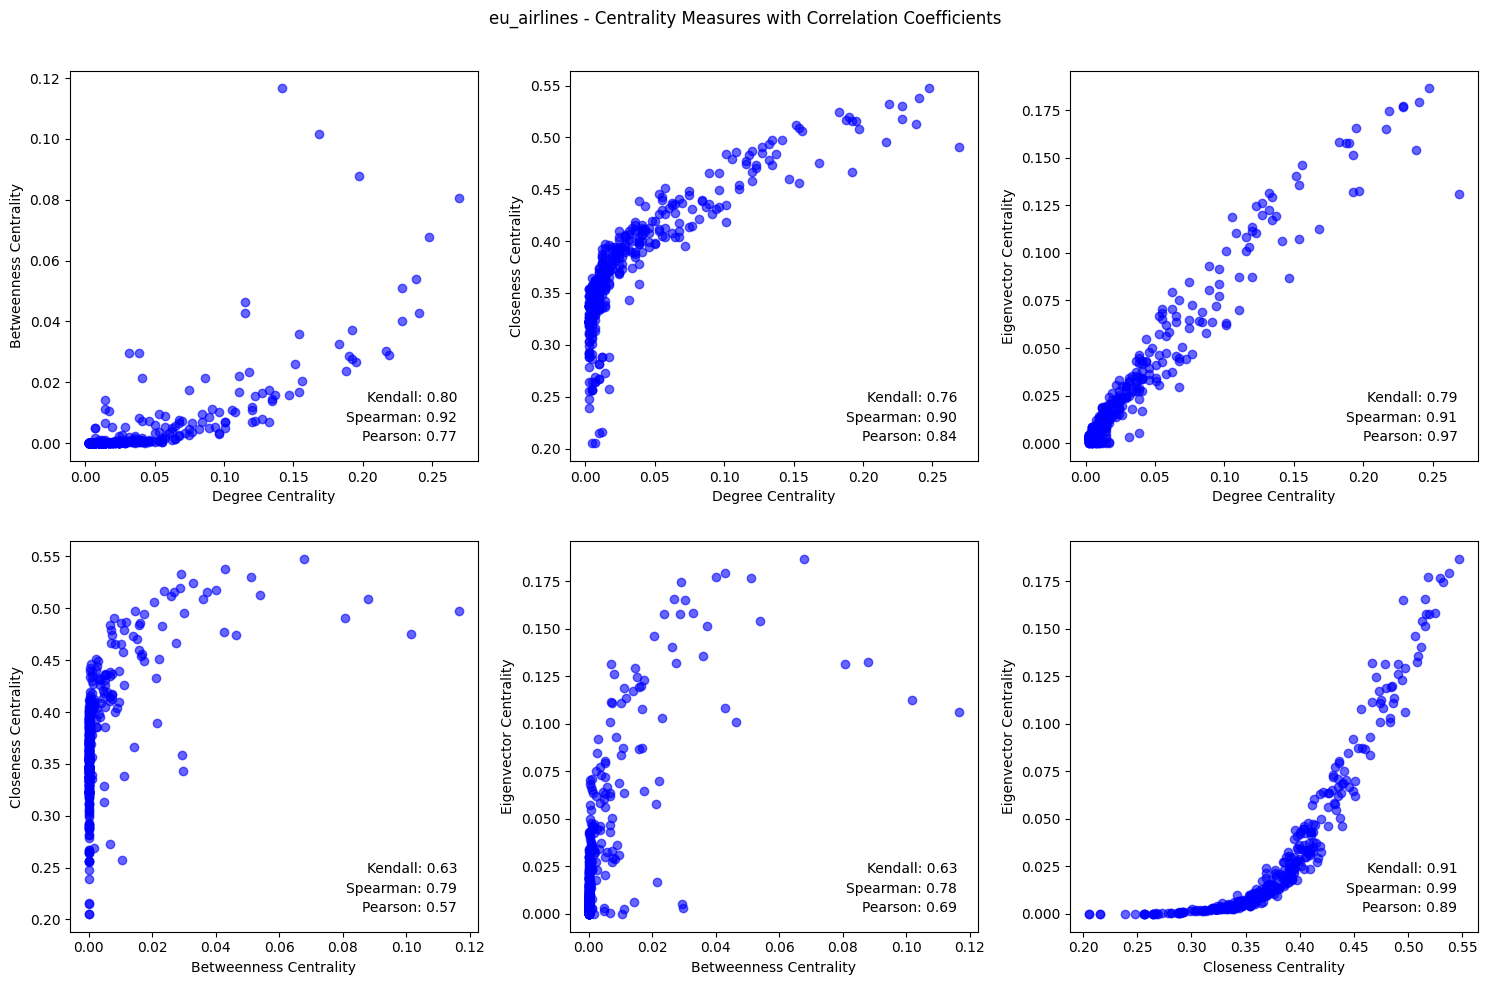

In [185]:
# centralities
def compute_centralities(G):
    degree = list(nx.degree_centrality(G).values())
    betweenness = list(nx.betweenness_centrality(G).values())
    closeness = list(nx.closeness_centrality(G).values())
    eigenvector = list(nx.eigenvector_centrality(G).values())

    return degree, betweenness, closeness, eigenvector

# Scatter plot per pair
def scatter_with_correlations(x, y, xlabel, ylabel, ax):
    ax.scatter(x, y, alpha=0.6, color="b")
    set_ax_labels(ax, xlabel, ylabel, '')

    # coefficients
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    kendall_corr, _ = kendalltau(x, y)

    # Annotate figure with annoation
    ax.annotate(f'Pearson: {pearson_corr:.2f}', xy=(0.95, 0.05), xycoords='axes fraction', fontsize=10, horizontalalignment='right')
    ax.annotate(f'Spearman: {spearman_corr:.2f}', xy=(0.95, 0.10), xycoords='axes fraction', fontsize=10, horizontalalignment='right')
    ax.annotate(f'Kendall: {kendall_corr:.2f}', xy=(0.95, 0.15), xycoords='axes fraction', fontsize=10, horizontalalignment='right')


def plot_centrality_correlations(G, name):
    # centralities
    degree, betweenness, closeness, eigenvector = compute_centralities(G)

    # 2x3 subplots (1 per pair)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
 
    # correlation pair + axis labels
    centrality_pairs = [
        (degree, betweenness, 'Degree Centrality', 'Betweenness Centrality'),
        (degree, closeness, 'Degree Centrality', 'Closeness Centrality'),
        (degree, eigenvector, 'Degree Centrality', 'Eigenvector Centrality'),
        (betweenness, closeness, 'Betweenness Centrality', 'Closeness Centrality'),
        (betweenness, eigenvector, 'Betweenness Centrality', 'Eigenvector Centrality'),
        (closeness, eigenvector, 'Closeness Centrality', 'Eigenvector Centrality')
    ]

    # Loop through pairs and plot scatter plots
    for ax, (x, y, xlabel, ylabel) in zip(axes.flatten(), centrality_pairs):
        scatter_with_correlations(x, y, xlabel, ylabel, ax)

    fig.suptitle(f"{name} - Centrality Measures with Correlation Coefficients")
    plt.tight_layout(rect=[0, 0, 1, 0.99])

# Example usage with a sample graph G
for i, g in enumerate(data_lst):
    plot_centrality_correlations(g, data_names[i])
